In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
from astropy.table import Table
from astropy.constants import G, c, k_B, sigma_sb, m_p
import simple_disk as sd
from matplotlib import pyplot as plt
import numpy as np
from numpy import pi as pi
import pandas as pd
import seaborn as sns
sns.set_palette("icefire")
cmap = sns.color_palette("icefire", as_cmap=True)
palette = sns.color_palette("icefire", n_colors=10)
palette

In [52]:
class testvars:
    M = 1e8 * u.Msun
    gRad = (G * M / c / c)
    Mdot = 1e23 * u.kg / u.s 
    alpha = 0.1
    Rstar = (6-(1e-5)) * (G * M / c / c)
    mu = 0.6
    k0 = 0.4 * u.cm**2 / u.g
    k1 = 6.4e22 * u.cm**5 / u.g**2 * u.K**(7/2)
    rvals = None  # Set after class definition
    #for type I migration
    mbh = 1*u.Msun
    adiabatic_index = 2/3

testvars.rvals = [r * testvars.gRad for r in np.logspace(1, 7, 200)]

In [53]:
def f1(Tc, R):
    f = (1-np.sqrt(testvars.Rstar/R))
    Omega = np.sqrt(G*testvars.M / R**3)

    A = k_B  / (testvars.mu * m_p) #Tc
    B = 4 * sigma_sb / (3*c) #Tc4
    C = (testvars.Mdot * f * Omega ** 2 / (3 * pi * testvars.alpha) ) ** (2/3) #Tc0

    D = testvars.k0 #Tc0
    E = testvars.k1 #Tc^(-7/2)
    F = (   (32 * pi * sigma_sb * Omega * R**3) * (3 * pi * testvars.alpha) / 
        (9 * G * testvars.M * testvars.Mdot * f) / (testvars.Mdot * f * Omega**2)**(1/3)  ) #Tc4
    
    def rho(Tc):
        
        a = (C * E / F) * Tc**(-15/2)
        b = (C * D / F)*Tc**(-4) - (A * Tc)
        cee = - B * Tc**(4)

        rho_plus = (-b + np.sqrt(b**2 - 4*a*cee))/(2*a)
        rho_minus = (-b - np.sqrt(b**2 - 4*a*cee))/(2*a)
        return rho_plus
    
    return rho(Tc)**(2/3) * (D + (E * Tc**(-7/2) * rho(Tc))) - F * Tc**4 

f1(Tc = 1e5 * u.K, R=(10 * u.AU))

<Quantity -7.45300823e-11 1 / g(1/3)>

In [54]:
def f1prime(Tc, R):
    
    f = (1-np.sqrt(testvars.Rstar/R))
    Omega = np.sqrt(G*testvars.M / R**3)

    A = k_B  / (testvars.mu * m_p) #Tc
    B = 4 * sigma_sb / (3*c) #Tc4
    C = (testvars.Mdot * f * Omega ** 2 / (3 * pi * testvars.alpha) ) ** (2/3) #Tc0

    D = testvars.k0 #Tc0
    E = testvars.k1 #Tc^(-7/2)
    F = (   (32 * pi * sigma_sb * Omega * R**3) * (3 * pi * testvars.alpha) / 
        (9 * G * testvars.M * testvars.Mdot * f) / (testvars.Mdot * f * Omega**2)**(1/3)  ) #Tc4
    
    def rho(Tc):
        
        a = (C * E / F) * Tc**(-15/2)
        b = (C * D / F)*Tc**(-4) - (A * Tc)
        cee = - B * Tc**(4)

        rho_plus = (-b + np.sqrt(b**2 - 4*a*cee))/(2*a)
        
        return rho_plus
    def dRho(Tc):
        a1 = (C * E / F)
        b1 = (C * D / F)
        b2 = A 
        c1 = -B
        dscrm = 4 * a1 * c1 * Tc**(9/2)

        t1 = 17 * b2 * Tc**5 - 7 * b1


        t2radical = (b2 * Tc**5 - b1)**2 - dscrm
        t2 = (np.sqrt(t2radical))+ (b2*Tc**5) - b1
        numerator = Tc**(5/2) * (   (t1) * (t2) - (46 * a1 * c1 * Tc**(9/2))   )
        denominator = 4 * a1 * np.sqrt((b2*Tc**5 - b1)**2 - dscrm)
        return (numerator / denominator).cgs
    
    rhotc = rho(Tc)
    drhotc = dRho(Tc)

    top = (E * rhotc * (10 * Tc * drhotc - 21*rhotc)) + 4 * Tc**(9/2) * (D * drhotc - 6 * F * Tc**3 * (rhotc)**(1/3))
    bottom = 6 * Tc**(9/2) * (rhotc)**(1/3)

    return top/bottom
    
    
f1prime(Tc=1e6 * u.K, R=10*testvars.gRad).si.value

np.float64(1.554977086903127e-10)

In [55]:
def fq(Tc, R):
    Qmin = 1
    Omega = np.sqrt(G*testvars.M / R**3)
    f = (1-np.sqrt(testvars.Rstar/R))
    rho = Omega**2 / (2*pi*G*Qmin)
    C1 = 4*sigma_sb/3/c 
    C2 = rho*k_B / (testvars.mu*m_p)
    C3 = rho*( (testvars.Mdot * f * Omega**2) / (3 * pi * testvars.alpha * rho) )**(2/3)
    return (C1 * Tc**4) + C2*Tc - C3 

In [56]:
def fqprime(Tc, R):
    Qmin = 1
    Omega = np.sqrt(G*testvars.M / R**3)
    f = (1-np.sqrt(testvars.Rstar/R))
    rho = Omega**2 / (2*pi*G*Qmin)
    C1 = 4*sigma_sb/3/c 
    C2 = rho*k_B / (testvars.mu*m_p)
    
    return 4 * C1 * Tc**3 + C2 

In [57]:
def line(x, a, x1, y1):
    return a * (x - x1) + y1
TcVals = []
ftc = []
fprimetc = []
Rtest = 10 * testvars.gRad
for tc in np.linspace(1000, (10**7), 200):
    TcVals.append(tc * u.K)
    ftc.append(f1(Tc=(tc*u.K), R=Rtest))
    fprimetc.append(f1prime(Tc=(tc*u.K), R=Rtest))

x0 = 0.9e6 * u.K #Change this to test different points
slope = f1prime(Tc=x0, R=Rtest)
y0 = f1(Tc=x0, R=Rtest)

deriv = [line(a=slope, x1=x0, y1=y0, x=t) for t in TcVals]

/home/mars/.local/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 1.0, 'Derivative Visual Check')

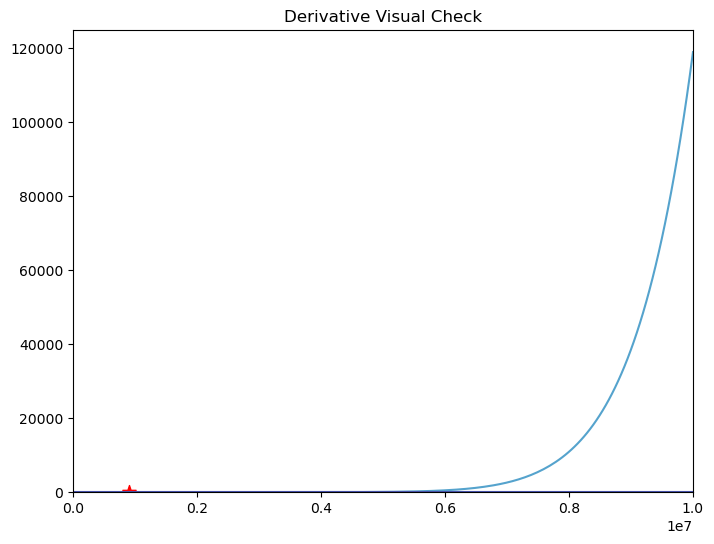

In [58]:
fig, ax = plt.subplots(figsize=(8,6))
sns.lineplot(ax=ax, x=[Tc.si.value for Tc in TcVals], 
                y=[f_tc.si.value for f_tc in ftc])
ax.scatter(x=[x0.si.value], y=[y0.si.value], color="red", s=100, marker="*")
sns.lineplot(ax=ax, x=[Tc.si.value for Tc in TcVals], 
             y=[d.si.value for d in deriv])
ax.set_ylim(bottom=0)
ax.set_xlim(0, max(TcVals).si.value)
ax.set_title("Derivative Visual Check")


In [59]:
def newton(tc_initial_guess, R_in, max_iter=5, abs_err_tol=1, slow=False, verbose=False, return_convergence=False):
    tcn = tc_initial_guess
    tc_iters = [tc_initial_guess]
    abs_err_prev = 1e10
    converged = False
    if slow:
        curve_iters = [f1(tc_initial_guess, R=R_in)]
    for i in range(0, max_iter):
        
        fn = f1(Tc=tcn, R=R_in)
        dfn = f1prime(Tc=tcn, R=R_in)

        if verbose:
            print(f"(n:{i}) Updating Tc_n = {tcn.si} - {(fn/dfn).si} \n")

        #Tc_{n+1}    
        tcnext = tcn - (fn/dfn)
        tc_iters.append(tcnext.si)
        abs_err = np.abs(tcnext - tcn).si.value
        
        if abs_err <= abs_err_tol:
            converged = True
            if verbose:
                print(f"Absolute Error |tcnext - tccurrent|: {abs_err:.5e} <= {abs_err_tol:.5e}\nConverged after {i} iterations!")
            break
        else:
            if verbose:
                print(f"Absolute Error |tcnext - tccurrent|: {abs_err:.5e} > {abs_err_tol:.5e}")
        if slow:
            f_eval = f1(Tc=tcnext, R=R_in).si
            curve_iters.append(f_eval)

        if (abs_err > abs_err_prev):
            raise Exception("Diverged!")

        tcn = tcnext
        del(tcnext)
    

    if slow:
        if return_convergence:
            return tc_iters[-1], tc_iters, curve_iters, converged
        return tc_iters[-1], tc_iters, curve_iters
    
    if return_convergence:
        return tc_iters[-1], converged
    
    return tc_iters[-1]
        

        

tc_ig = 10**(5.5) * u.K #Replace with initial guess from power law solution
Rtest = 10 * testvars.gRad
TcOut, TcSteps, CurveSteps = newton(tc_initial_guess=tc_ig, R_in=Rtest, max_iter=6, abs_err_tol=1, slow=True, verbose=True)

(n:0) Updating Tc_n = 316227.7660168379 K - -89450.12967310697 K 

Absolute Error |tcnext - tccurrent|: 8.94501e+04 > 1.00000e+00
(n:1) Updating Tc_n = 405677.89568994485 K - 32285.105872532546 K 

Absolute Error |tcnext - tccurrent|: 3.22851e+04 > 1.00000e+00
(n:2) Updating Tc_n = 373392.7898174123 K - 13621.14724889918 K 

Absolute Error |tcnext - tccurrent|: 1.36211e+04 > 1.00000e+00
(n:3) Updating Tc_n = 359771.64256851317 K - 2376.2498343613934 K 

Absolute Error |tcnext - tccurrent|: 2.37625e+03 > 1.00000e+00
(n:4) Updating Tc_n = 357395.3927341518 K - 67.20181162975035 K 

Absolute Error |tcnext - tccurrent|: 6.72018e+01 > 1.00000e+00
(n:5) Updating Tc_n = 357328.19092252204 K - 0.052687152722344144 K 

Absolute Error |tcnext - tccurrent|: 5.26872e-02 <= 1.00000e+00
Converged after 5 iterations!


(-1.2323641123431333e-08, 5.002851300641931e-08)

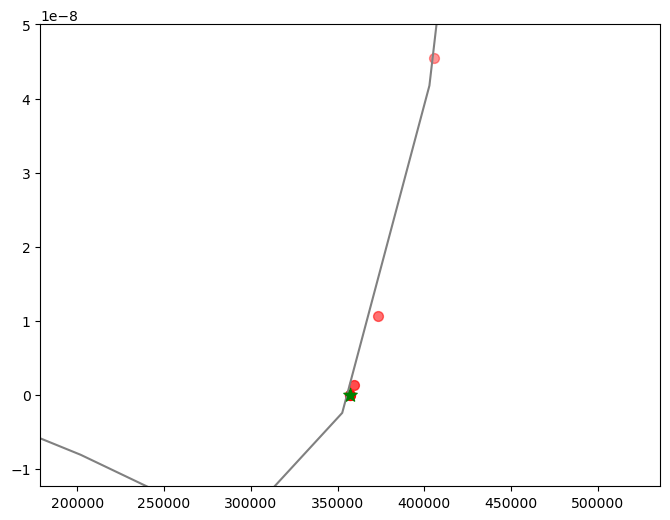

In [60]:
fig, ax = plt.subplots(figsize=(8,6))
sns.lineplot(ax=ax, x=[Tc.si.value for Tc in TcVals], 
                y=[f_tc.si.value for f_tc in ftc],color="grey")
av = 0.9/len(TcSteps)
for pair in zip(TcSteps, CurveSteps):
    av += 1/len(TcSteps)
    ax.scatter(x=[pair[0].si.value], y=[pair[1].si.value], color="red", s=50, alpha=float(av))
ax.scatter(x=TcOut, y=f1(Tc=TcOut, R=Rtest), color="green", s=100, marker="*",zorder=5)

ax.set_xlim(0.5*TcOut.si.value, 1.5*TcOut.si.value)
ax.set_ylim(0.9*min(CurveSteps).si.value, 1.1*max(CurveSteps).si.value)

In [61]:
def get_TcPowerLawSols(rvals=None, intersections=False):
    if rvals is None:
        rvals = testvars.rvals
    
    TcPowerLaw = {1:[], 2:[], 3:[]}
    for r in rvals:
        f = (1-np.sqrt(testvars.Rstar/r))
        fMdot = f*testvars.Mdot
        for z in [1,2,3]:
            TcPowerLaw[z].append(sd.T_central(alpha=testvars.alpha, M=testvars.M, fMdot=fMdot, r=r, zone=z, scale="AGN"))
    if not intersections:
        return TcPowerLaw
    tc = lambda z: np.array([t.si.value for t in TcPowerLaw[z]])
    mask = np.array([(r/testvars.gRad).value > 6 for r in rvals])
    cross = lambda a, b: [rvals[i] for i in np.where(mask[:-1] & (np.diff(np.sign(tc(a) - tc(b))) != 0))[0]]
    cross21 = cross(2, 1)
    cross32 = cross(3, 2)
    if cross21:
        cross21 = cross21[0]
    else:
        cross21 = None
    if cross32:
        cross32 = cross32[0]
    else:
        cross32 = None
    return TcPowerLaw, cross21, cross32

TcPowerLaw, cross21, cross32 = get_TcPowerLawSols(rvals=testvars.rvals, intersections=True)

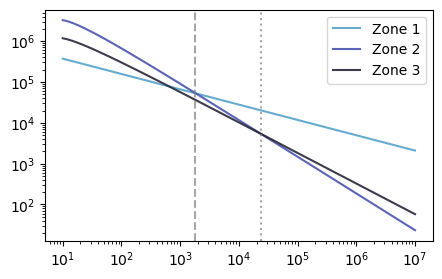

In [62]:
fig, ax = plt.subplots(figsize=(5,3))
for zone in [1,2,3]:
    sns.lineplot(ax=ax, x=[(r/testvars.gRad).value for r in testvars.rvals], y=[tc.si.value for tc in TcPowerLaw[zone]], alpha=0.9, label=f"Zone {zone}")
ax.axvline(x=(cross21/testvars.gRad).value, linestyle="--", color="grey", alpha=0.7)
ax.axvline(x=(cross32/testvars.gRad).value, linestyle=":", color="grey", alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")

In [63]:
def NewtonLastPoint(r_list=None):
    if r_list is None:
        rvals = testvars.rvals
    else:
        rvals = r_list

    TcPowerLaw = get_TcPowerLawSols(rvals=rvals)
    TcVals = []
    conv_cnt = 0
    divrg_cnt = 0
    for r in rvals:
        if len(TcVals) < 1:
            tc_ig = TcPowerLaw[1][0]
        else:
            tc_ig = TcVals[-1]
        

        try:
            TcOut, conv = newton(tc_initial_guess=tc_ig, R_in=r, max_iter=10, abs_err_tol=10, slow=False, verbose=False, return_convergence=True)
            if conv:
                conv_cnt += 1
        except Exception as e:
            TcVals.append(TcVals[-1])
            divrg_cnt += 1
            continue
        
        TcVals.append(TcOut)

        #I'm paranoid
        del(conv)
        del(TcOut)

    print(f"converged: {conv_cnt}")
    print(f"diverged: {divrg_cnt}")
    print(f"other: {len(rvals)-(conv_cnt+divrg_cnt)}")
    return rvals, TcVals #TODO change to dataframe

def NewtonPowerLawIG(r_list=None):
    if r_list is None:
        rvals = testvars.rvals
    else:
        rvals = r_list
    TcPowerLaw, z2start, z3start = get_TcPowerLawSols(rvals=rvals, intersections=True)
    if z2start is None:
        z2start = 6 * testvars.gRad
    if z3start is None:
        z3start = 10**(10) * testvars.gRad
    TcVals = []
    conv_cnt = 0
    divrg_cnt = 0
    for index, r in enumerate(rvals):
        
        
        if r < z2start:
            tc_ig = TcPowerLaw[1][index]
        elif (r >= z2start) and (r <= z3start):
            tc_ig = TcPowerLaw[2][index]
        elif r > z3start:
            tc_ig = TcPowerLaw[3][index]
            

        try:
            TcOut, conv = newton(tc_initial_guess=tc_ig, R_in=r, max_iter=10, abs_err_tol=10, slow=False, verbose=False, return_convergence=True)
            if conv:
                conv_cnt += 1
        except Exception as e:
            TcVals.append(TcVals[-1])
            divrg_cnt += 1
            continue
        
        TcVals.append(TcOut)

        #I'm paranoid
        del(conv)
        del(TcOut)
    
    print(f"converged: {conv_cnt}")
    print(f"diverged: {divrg_cnt}")
    print(f"other: {len(rvals)-(conv_cnt+divrg_cnt)}")
    return rvals, TcVals

In [64]:
#========================1/20/2026-SirkoGoodman===============
def newton_q(tc_initial_guess, R_in, max_iter=5, abs_err_tol=1, slow=False, verbose=False, return_convergence=False):
    """
    Newton-Raphson solver for the Sirko-Goodman (Q=1) disk solution.
    Uses fq() and fqprime() instead of f1() and f1prime().
    """
    tcn = tc_initial_guess
    tc_iters = [tc_initial_guess]
    abs_err_prev = 1e10
    converged = False
    if slow:
        curve_iters = [fq(tc_initial_guess, R=R_in)]
    for i in range(0, max_iter):
        
        fn = fq(Tc=tcn, R=R_in)
        dfn = fqprime(Tc=tcn, R=R_in)

        if verbose:
            print(f"(n:{i}) Updating Tc_n = {tcn.si} - {(fn/dfn).si} \n")

        # Tc_{n+1}    
        tcnext = tcn - (fn/dfn)
        tc_iters.append(tcnext.si)
        abs_err = np.abs(tcnext - tcn).si.value
        
        if abs_err <= abs_err_tol:
            converged = True
            if verbose:
                print(f"Absolute Error |tcnext - tccurrent|: {abs_err:.5e} <= {abs_err_tol:.5e}\nConverged after {i} iterations!")
            break
        else:
            if verbose:
                print(f"Absolute Error |tcnext - tccurrent|: {abs_err:.5e} > {abs_err_tol:.5e}")
        if slow:
            f_eval = fq(Tc=tcnext, R=R_in).si
            curve_iters.append(f_eval)

        if (abs_err > abs_err_prev):
            raise Exception("Diverged!")

        tcn = tcnext
        del(tcnext)
    

    if slow:
        if return_convergence:
            return tc_iters[-1], tc_iters, curve_iters, converged
        return tc_iters[-1], tc_iters, curve_iters
    
    if return_convergence:
        return tc_iters[-1], converged
    
    return tc_iters[-1]


# Quick test
tc_ig_q = 10**4 * u.K
Rtest_q = 10**5 * testvars.gRad
TcOut_q = newton_q(tc_initial_guess=tc_ig_q, R_in=Rtest_q, max_iter=10, abs_err_tol=1, verbose=True)
print(f"\nSirko-Goodman Tc at R = {(Rtest_q/testvars.gRad).value:.0f} Rg: {TcOut_q.si}")

(n:0) Updating Tc_n = 10000.0 K - 2488.835176498829 K 

Absolute Error |tcnext - tccurrent|: 2.48884e+03 > 1.00000e+00
(n:1) Updating Tc_n = 7511.164823501171 K - 1850.8587989155124 K 

Absolute Error |tcnext - tccurrent|: 1.85086e+03 > 1.00000e+00
(n:2) Updating Tc_n = 5660.306024585659 K - 1351.1449532372055 K 

Absolute Error |tcnext - tccurrent|: 1.35114e+03 > 1.00000e+00
(n:3) Updating Tc_n = 4309.161071348453 K - 930.8347429661146 K 

Absolute Error |tcnext - tccurrent|: 9.30835e+02 > 1.00000e+00
(n:4) Updating Tc_n = 3378.326328382339 K - 538.7745722958232 K 

Absolute Error |tcnext - tccurrent|: 5.38775e+02 > 1.00000e+00
(n:5) Updating Tc_n = 2839.5517560865155 K - 193.75870221584225 K 

Absolute Error |tcnext - tccurrent|: 1.93759e+02 > 1.00000e+00
(n:6) Updating Tc_n = 2645.7930538706732 K - 23.25128512419661 K 

Absolute Error |tcnext - tccurrent|: 2.32513e+01 > 1.00000e+00
(n:7) Updating Tc_n = 2622.5417687464765 K - 0.3105759252016203 K 

Absolute Error |tcnext - tccurrent

In [65]:
#========================1/20/2026-SirkoGoodman===============
def NewtonLastPoint_SirkoGoodman(r_list=None, init_Tc=(10**(4.5)*u.K)):
    """
    Solve for Tc using the Sirko-Goodman (Q=1) prescription.
    This solution applies at large radii where the standard disk becomes
    gravitationally unstable (Toomre Q < 1).
    
    Uses newton_q() which solves fq() = 0 (pressure balance at Q=1 density).
    """
    if r_list is None:
        rvals = [r*testvars.gRad for r in np.logspace(3.5, 8.0, 100)]
    else:
        rvals = r_list
    
    TcVals = []
    conv_cnt = 0
    divrg_cnt = 0
    for r in rvals:
        if len(TcVals) < 1:
            tc_ig = init_Tc
        else:
            tc_ig = TcVals[-1]
        
        try:
            TcOut, conv = newton_q(tc_initial_guess=tc_ig, R_in=r, max_iter=10, abs_err_tol=10, slow=False, verbose=False, return_convergence=True)
            if conv:
                conv_cnt += 1
        except Exception as e:
            TcVals.append(TcVals[-1])
            divrg_cnt += 1
            continue
        
        TcVals.append(TcOut)

        del(conv)
        del(TcOut)

    print(f"converged: {conv_cnt}")
    print(f"diverged: {divrg_cnt}")
    print(f"other: {len(rvals)-(conv_cnt+divrg_cnt)}")
    return rvals, TcVals

converged: 100
diverged: 0
other: 0


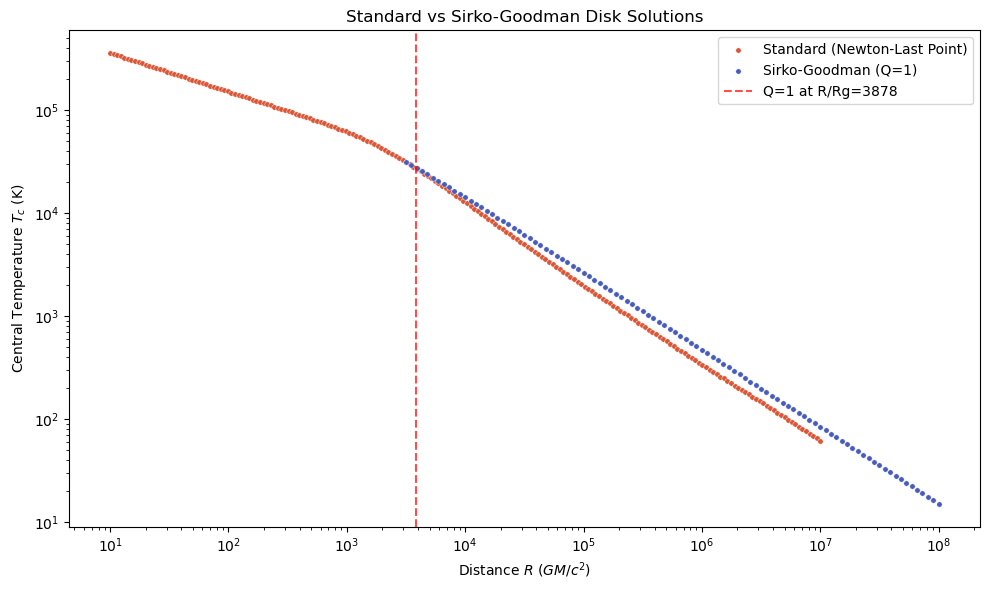

In [66]:
#========================1/20/2026-SirkoGoodman===============
# Test the Sirko-Goodman solution and compare with standard solution
rvals_sg, TcVals_sg = NewtonLastPoint_SirkoGoodman()

# Plot comparison: Standard vs Sirko-Goodman
fig, ax = plt.subplots(figsize=(10, 6))

# Standard solution (from earlier)
sns.scatterplot(ax=ax, x=[(r/testvars.gRad).value for r in testvars.rvals], 
                y=[tc.si.value for tc in TcVals_lastpoint], 
                label="Standard (Newton-Last Point)", s=15, color=palette[8])

# Sirko-Goodman solution
sns.scatterplot(ax=ax, x=[(r/testvars.gRad).value for r in rvals_sg], 
                y=[tc.si.value for tc in TcVals_sg], 
                label="Sirko-Goodman (Q=1)", s=15, color=palette[2])

# Mark Q=1 transition (where standard solution should switch to SG)
# Find where Q drops below 1 in df
q_transition_idx = np.where(df['Q'].values < 1)[0]
if len(q_transition_idx) > 0:
    q_transition_r = df['R/Rg'].values[q_transition_idx[0]]
    ax.axvline(x=q_transition_r, linestyle='--', color='red', alpha=0.7, label=f'Q=1 at R/Rg={q_transition_r:.0f}')

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Distance $R$ ($GM/c^2$)")
ax.set_ylabel(r"Central Temperature $T_c$ (K)")
ax.set_title("Standard vs Sirko-Goodman Disk Solutions")
ax.legend(loc="upper right")
plt.tight_layout()

In [67]:
rvals, TcVals_powerlaw = NewtonPowerLawIG()

/home/mars/.local/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


converged: 179
diverged: 0
other: 21


In [68]:
rvals, TcVals_lastpoint = NewtonLastPoint()

converged: 200
diverged: 0
other: 0


/tmp/ipykernel_86911/4102163202.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,5e6)


Text(0, 0.5, 'Central Temperature $T_c$ (K)')

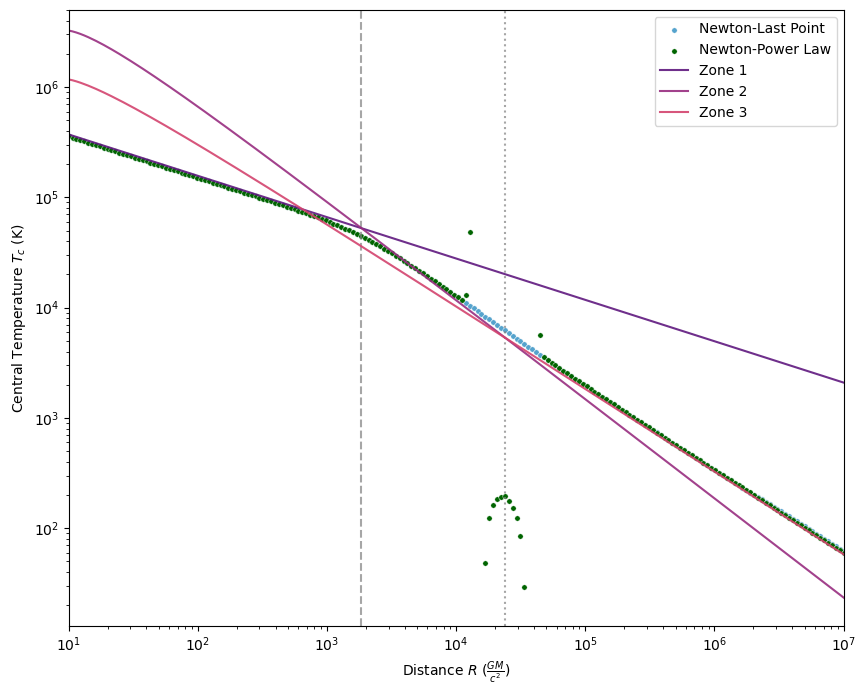

In [69]:
fig, ax = plt.subplots(figsize=(10,8))
sns.scatterplot(ax=ax, x=[(r/testvars.gRad).value for r in testvars.rvals], y=[tc.si.value for tc in TcVals_lastpoint], label="Newton-Last Point", s=15)
sns.scatterplot(ax=ax, x=[(r/testvars.gRad).value for r in testvars.rvals], y=[tc.si.value for tc in TcVals_powerlaw], label="Newton-Power Law", s=15, color="darkgreen")
ax.axvline(x=(cross32/testvars.gRad).value, linestyle=":", color="grey", alpha=0.7)
ax.axvline(x=(cross21/testvars.gRad).value, linestyle="--", color="grey", alpha=0.7)
for zone in [1,2,3]:
    sns.lineplot(ax=ax, x=[(r/testvars.gRad).value for r in testvars.rvals], y=[tc.si.value for tc in TcPowerLaw[zone]], alpha=0.9, label=f"Zone {zone}", color=sns.color_palette("magma")[zone])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(0,5e6)
ax.set_xlim(10,1e7)
ax.set_xlabel(r"Distance $R$ ($\frac{GM}{c^2}$)")
ax.set_ylabel(r"Central Temperature $T_c$ (K)")

In [70]:
def full_disk_solution(r_vals):
    
    rvals = r_vals
    rvals, TcVals = NewtonLastPoint(r_list = rvals)

    def Rho(Tc, R):
        assert Tc.unit.physical_type == "temperature" and R.unit.physical_type == "length"
        f = (1-np.sqrt(testvars.Rstar/R))
        Omega = np.sqrt(G*testvars.M / R**3)

        A = k_B  / (testvars.mu * m_p) #Tc
        B = 4 * sigma_sb / (3*c) #Tc4
        C = (testvars.Mdot * f * Omega ** 2 / (3 * pi * testvars.alpha) ) ** (2/3) #Tc0

        D = testvars.k0 #Tc0
        E = testvars.k1 #Tc^(-7/2)
        F = (   (32 * pi * sigma_sb * Omega * R**3) * (3 * pi * testvars.alpha) / 
            (9 * G * testvars.M * testvars.Mdot * f) / (testvars.Mdot * f * Omega**2)**(1/3)  ) #Tc4

        a1 = (C * E / F) * Tc**(-15/2)
        b1 = (C * D / F)*Tc**(-4) - (A * Tc)
        c1 = - B * Tc**(4)

        rho_plus = (-b1 + np.sqrt(b1**2 - 4*a1*c1))/(2*a1)
        #rho_minus = (-b1 - np.sqrt(b1**2 - 4*a1*c1))/(2*a1)

        return rho_plus     

    def P(Tc, rho):
        assert Tc.unit.physical_type == "temperature" and rho.unit.physical_type == "mass density"
        t1 = rho * k_B * Tc / (testvars.mu * m_p)
        t2 = 4 * sigma_sb * Tc**4 / (3 * c)
        return (t1 + t2).si

    def cs(P, rho):
        assert P.unit.physical_type == "pressure" and rho.unit.physical_type == "mass density"
        return np.sqrt(P/rho).si

    def H(cs, R):
        assert cs.unit.physical_type == "speed" and R.unit.physical_type == "length"
        Omega = np.sqrt(G*testvars.M / R**3)
        return (cs / Omega).si

    def visc(cs, H):
        assert cs.unit.physical_type == "speed" and H.unit.physical_type == "length"
        return (testvars.alpha * cs * H).si

    def Sigma(visc, R):
        assert visc.unit.physical_type == "kinematic viscosity" and R.unit.physical_type == "length"
        f = (1-np.sqrt(testvars.Rstar/R))
        RHS = testvars.Mdot * f / (3 * pi)
        return (RHS/visc).cgs

    def tau(Sigma, rho, Tc):
        assert Sigma.unit.physical_type == "surface mass density" and rho.unit.physical_type == "mass density" and Tc.unit.physical_type == "temperature"
        prscr = testvars.k0 + testvars.k1*rho*(Tc**(-7/2))
        return (Sigma * prscr).si

    def toomreQ(Sigma, cs, R):
        assert Sigma.unit.physical_type == "surface mass density" and cs.unit.physical_type == "speed"
        Omega = np.sqrt(G*testvars.M / R**3)
        return (cs * Omega) / (pi * G * Sigma)

    
    rows = []
    for R, Tc in zip(rvals, TcVals):
        row = {}
        rhoi = Rho(Tc, R).si
        Pi = P(Tc=Tc, rho=rhoi).si
        csi = cs(P=Pi,rho=rhoi).si
        Hi = H(cs=csi, R=R).si
        visci = visc(cs=csi, H=Hi).si
        Sigmai = Sigma(visc=visci, R=R).si
        taui = tau(Sigma=Sigmai, rho=rhoi, Tc=Tc).si
        toomreQi = toomreQ(Sigma=Sigmai, cs=csi, R=R).si
        
        row["R"] = R.si.value
        row["R/Rg"] = (R / testvars.gRad).value
        row["Tc"] = Tc.si.value
        row["rho"] = rhoi.value
        row["P"] = Pi.value
        row["cs"] = csi.value
        row["H"] = Hi.value
        row["visc"] = visci.value
        row["Sigma"] = Sigmai.si.value
        row["tau"] = taui.si.value
        row["Q"] = toomreQi.si.value
        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
#========================1/20/2026-SirkoGoodman===============
def self_regulating_solution(r_vals, Qmin=1):
    """
    Compute disk solution for the self-regulating (Q=Qmin) outer disk.
    Analogous to full_disk_solution() but uses the Sirko-Goodman prescription.
    """
    rvals = r_vals

    rvals, TcVals = NewtonLastPoint_SirkoGoodman(r_list=rvals)

    rows = []
    for R, Tc in zip(rvals, TcVals):
        nr = {}
        nr["R"] = R.si.value 
        nr["R/Rg"] = (R / testvars.gRad).decompose().value  # Fixed: removed .si
        nr["Tc"] = Tc.si.value

        f = (1 - np.sqrt(testvars.Rstar / R))
        Omega = np.sqrt(G * testvars.M / R**3)
        rho = Omega**2 / (2 * pi * G * Qmin)
        cs = ((testvars.Mdot * f * Omega**2) / (3 * pi * testvars.alpha * rho))**(1/3)
        P = cs**2 * rho 
        H = cs / Omega 
        visc = testvars.alpha * cs * H 
        Sigma = testvars.Mdot * f / (3 * pi * visc) 
        Q = cs * Omega / (pi * G * Sigma)

        nr["rho"] = rho.si.value
        nr["P"] = P.si.value
        nr["cs"] = cs.si.value
        nr["H"] = H.si.value
        nr["visc"] = visc.si.value
        nr["Sigma"] = Sigma.si.value
        nr["Q"] = Q.decompose().value  # Q is dimensionless

        rows.append(nr)  # <-- CRITICAL FIX: was missing!

    return pd.DataFrame(rows)

In [71]:
# calc power law solutions for all variables
def get_powerlaw_df(rvals=None):
    if rvals is None:
        rvals = testvars.rvals
    rows = []
    for zone in [1, 2, 3]:
        for r in rvals:
            f = (1-np.sqrt(testvars.Rstar/r))
            fMdot = f * testvars.Mdot
            Tc = sd.T_central(alpha=testvars.alpha, M=testvars.M, fMdot=fMdot, r=r, zone=zone, scale="AGN")
            rhov = sd.rho(alpha=testvars.alpha, M=testvars.M, fMdot=fMdot, r=r, zone=zone, scale="AGN")
            P = sd.pressure(alpha=testvars.alpha, M=testvars.M, fMdot=fMdot, r=r, zone=zone, scale="AGN")
            H = sd.h(alpha=testvars.alpha, M=testvars.M, fMdot=fMdot, r=r, zone=zone, scale="AGN")
            Sig = sd.Sigma(alpha=testvars.alpha, M=testvars.M, fMdot=fMdot, r=r, zone=zone, scale="AGN")
            tau = sd.tau_es(alpha=testvars.alpha, M=testvars.M, fMdot=fMdot, r=r, zone=zone, scale="AGN")
            cs = np.sqrt(P / rhov).si
            visc = (testvars.alpha * cs * H).si
            rows.append({
                "R/Rg": (r / testvars.gRad).value,
                "Tc": Tc.si.value, "rho": rhov.si.value, "P": P.si.value,
                "cs": cs.value, "H": H.si.value, "visc": visc.value,
                "Sigma": Sig.si.value, "tau": tau.si.value, "zone": zone
            })
    return pd.DataFrame(rows)



In [72]:
testvars.rvals = [r * testvars.gRad for r in np.logspace(1,7,300)]

df = full_disk_solution(r_vals=testvars.rvals)
df_powerlaw = get_powerlaw_df(rvals=testvars.rvals)
df.head()

converged: 300
diverged: 0
other: 0


,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,tau,Q
0,1.476625e+12,10.000000,357328.138280,7.151947e-09,4.111519e+06,2.397668e+07,3.734553e+11,8.954217e+17,2670.931999,106.837284,2.748660e+09
1,1.546454e+12,10.472898,351190.037541,6.590203e-09,3.836208e+06,2.412691e+07,4.027648e+11,9.717470e+17,2654.301877,106.172079,2.596844e+09
2,1.619586e+12,10.968160,345157.355742,6.156470e-09,3.579331e+06,2.411210e+07,4.314051e+11,1.040208e+18,2655.932364,106.237299,2.419983e+09
3,1.696176e+12,11.486843,339228.285274,5.818850e-09,3.339654e+06,2.395699e+07,4.593912e+11,1.100563e+18,2673.128791,106.925156,2.228980e+09
4,1.776388e+12,12.030053,333401.050029,5.555355e-09,3.116027e+06,2.368343e+07,4.867383e+11,1.152763e+18,2704.004295,108.160176,2.032501e+09


In [73]:
"""
IGNORE -> NOT FINISHED
#Type I migration torques (http://arxiv.org/abs/2307.07546) eq. 12-16
q = testvars.mbh/testvars.M

Omega = np.sqrt(G*testvars.M / R**3)

Gamma0 = q**2 * Sigma * R**4 * Omega**2 * (H/R)**(-3)


#thermal diffusivity

Xnumerator = 16 * testvars.adiabatic_index * (testvars.adiabatic_index-1)*sigma_sb*Tc**4
Xdenominator = 3 * avg_opacity * rho0**2 * H**2 * Omega**2
X = Xnumerator / Xdenominator

x = X/(H**2 * Omega)

def f_gamma(x):
    top = np.sqrt(x/2) + (1/testvars.adiabatic_index)
    bottom = np.sqrt(x/2)+1
    return top/bottom

C_L = (-2.34 + 0.1 * dSigma - 1.5*dT)*f_gamma(x)

C_I = C_L + (0.46 - 0.96*dSigma + 1.8 * dT)/testvars.adiabatic_index

net_torque = C_I * (H/R) * Gamma0
"""

'\nIGNORE -> NOT FINISHED\n#Type I migration torques (http://arxiv.org/abs/2307.07546) eq. 12-16\nq = testvars.mbh/testvars.M\n\nOmega = np.sqrt(G*testvars.M / R**3)\n\nGamma0 = q**2 * Sigma * R**4 * Omega**2 * (H/R)**(-3)\n\n\n#thermal diffusivity\n\nXnumerator = 16 * testvars.adiabatic_index * (testvars.adiabatic_index-1)*sigma_sb*Tc**4\nXdenominator = 3 * avg_opacity * rho0**2 * H**2 * Omega**2\nX = Xnumerator / Xdenominator\n\nx = X/(H**2 * Omega)\n\ndef f_gamma(x):\n    top = np.sqrt(x/2) + (1/testvars.adiabatic_index)\n    bottom = np.sqrt(x/2)+1\n    return top/bottom\n\nC_L = (-2.34 + 0.1 * dSigma - 1.5*dT)*f_gamma(x)\n\nC_I = C_L + (0.46 - 0.96*dSigma + 1.8 * dT)/testvars.adiabatic_index\n\nnet_torque = C_I * (H/R) * Gamma0\n'

In [74]:
palette

[(0.48183174, 0.73401449, 0.80839675),
 (0.248686, 0.56358255, 0.80961366),
 (0.27690355, 0.3607736, 0.73659374),
 (0.23018113, 0.22132414, 0.39945577),
 (0.13405762, 0.13188822, 0.16820842),
 (0.17797765, 0.11994436, 0.13058435),
 (0.38288348, 0.16254006, 0.2163249),
 (0.65988195, 0.18734638, 0.26543435),
 (0.86286243, 0.33312058, 0.20274969),
 (0.95020929, 0.5832232, 0.34508419)]

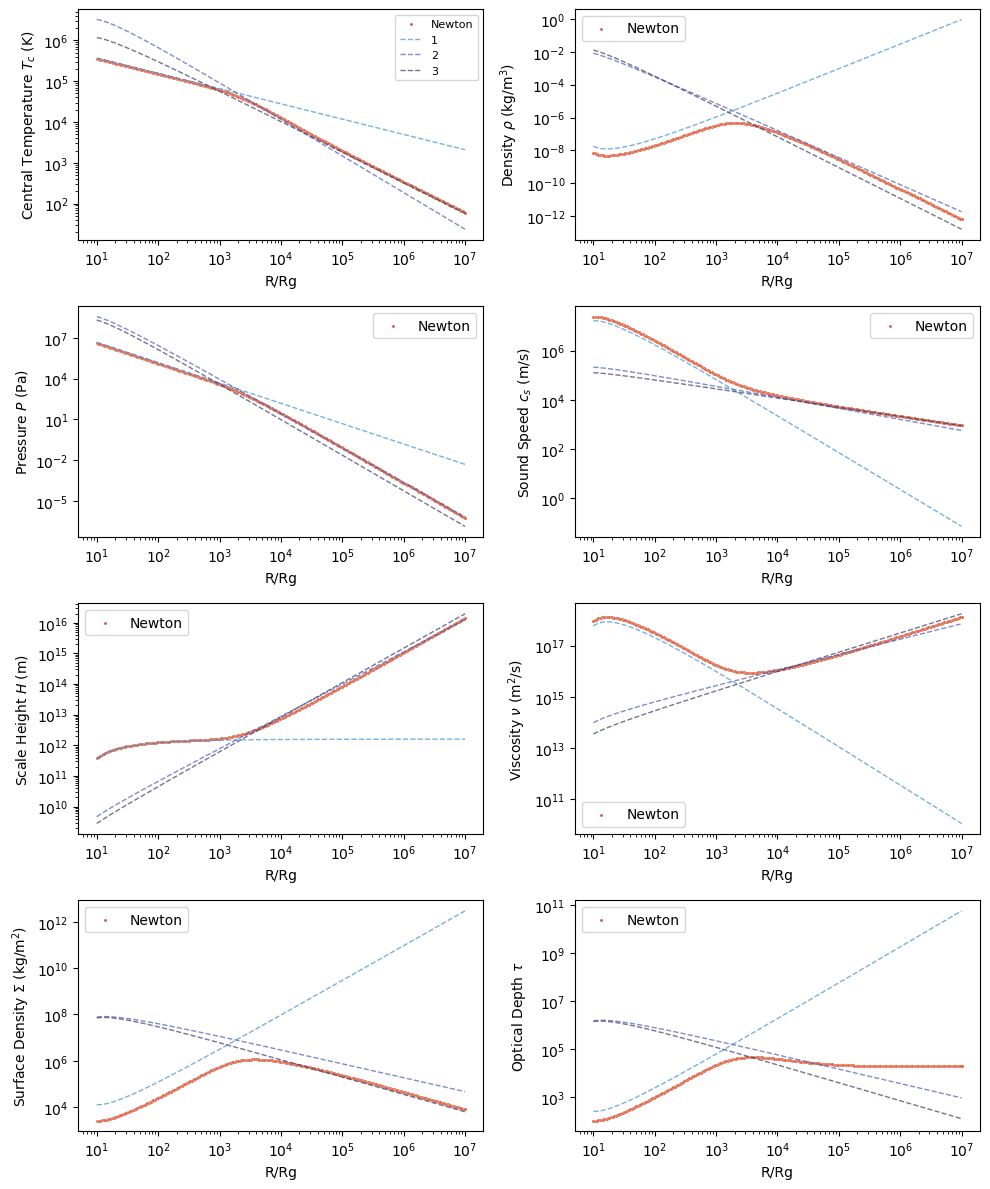

In [75]:
#DISK.PLOT EXAMPLE
fig, axs = plt.subplots(4, 2, figsize=(10, 12))
axs = axs.flatten()
cols = ["Tc", "rho", "P", "cs", "H", "visc", "Sigma", "tau"]
ylabels = [r"Central Temperature $T_c$ (K)", r"Density $\rho$ (kg/m$^3$)", 
           r"Pressure $P$ (Pa)", r"Sound Speed $c_s$ (m/s)",
           r"Scale Height $H$ (m)", r"Viscosity $\nu$ (m$^2$/s)",
           r"Surface Density $\Sigma$ (kg/m$^2$)", r"Optical Depth $\tau$"]
for i, col in enumerate(cols):
    sns.scatterplot(ax=axs[i], data=df, x="R/Rg", y=col, s=5, color=palette[8], label="Newton")
    sns.lineplot(ax=axs[i], data=df_powerlaw, x="R/Rg", y=col, hue="zone", 
                    palette=[palette[1], palette[2], palette[3]], alpha=0.7, legend=(i==0), linestyle="--", lw=1)
    axs[i].set_xscale("log")
    axs[i].set_yscale("log")
    axs[i].set_ylabel(ylabels[i])
axs[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()

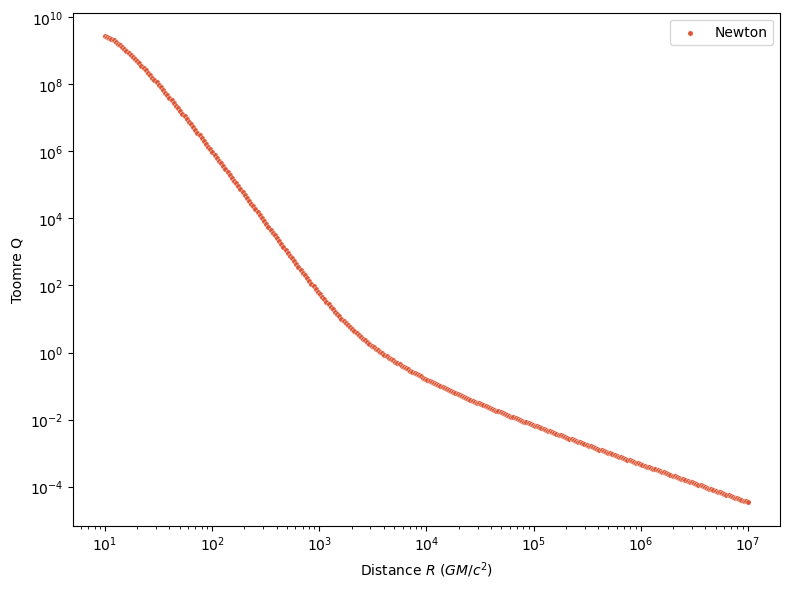

In [76]:
col = "Q"  # "Tc", "rho", "P", "cs", "H", "visc", "Sigma", "tau"

ylabels = {"Tc": r"Central Temperature $T_c$ (K)", "rho": r"Density $\rho$ (kg/m$^3$)", 
           "P": r"Pressure $P$ (Pa)", "cs": r"Sound Speed $c_s$ (m/s)",
           "H": r"Scale Height $H$ (m)", "visc": r"Viscosity $\nu$ (m$^2$/s)",
           "Sigma": r"Surface Density $\Sigma$ (kg/m$^2$)", "tau": r"Optical Depth $\tau$", "Q":"Toomre Q"}

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(ax=ax, data=df, x="R/Rg", y=col, s=15, color=palette[8], label="Newton", markers=".", zorder=5)
#sns.lineplot(ax=ax, data=df_powerlaw, x="R/Rg", y=col, hue="zone", palette=[palette[1], palette[2], palette[3]], alpha=0.7, linestyle="--", lw=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Distance $R$ ($GM/c^2$)")
ax.set_ylabel(ylabels[col])
ax.legend(loc="best")
plt.tight_layout()

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,tau,Q
0,1.476625e+12,10.000000,357328.138181,7.151988e-09,4.111519e+06,2.397661e+07,3.734542e+11,8.954166e+17,2670.939643,106.837590,2.748645e+09
1,1.582782e+12,10.718913,348145.476994,6.358560e-09,3.704899e+06,2.413842e+07,4.172386e+11,1.007148e+18,2653.036586,106.121468,2.510350e+09
2,1.696570e+12,11.489510,339198.750586,5.817382e-09,3.338492e+06,2.395584e+07,4.595292e+11,1.100841e+18,2673.256896,106.930280,2.227990e+09
3,1.818538e+12,12.315506,330481.908415,5.444838e-09,3.008321e+06,2.350550e+07,5.003772e+11,1.176162e+18,2724.472553,108.978907,1.932874e+09
4,1.949276e+12,13.200884,321989.049178,5.191458e-09,2.710802e+06,2.285095e+07,5.398316e+11,1.233567e+18,2802.512988,112.100524,1.646065e+09


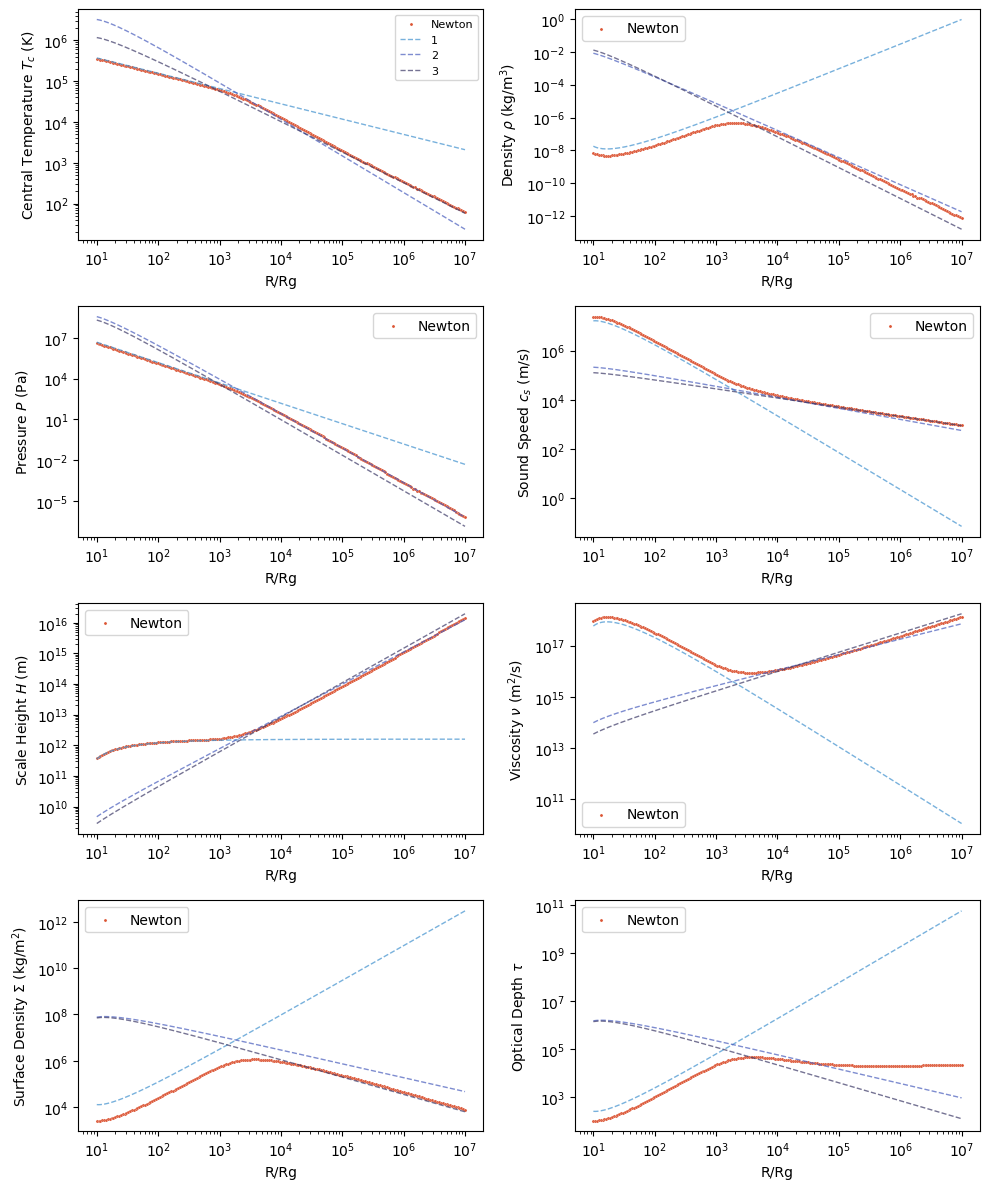

In [77]:
# EXAMPLE USAGE OF DISKTAB.py

from disktab import AGNDisk

# Create disk object and set physical parameters
disk = AGNDisk()
disk.M = 1e8 * u.Msun          # Central black hole mass
disk.Mdot = 1e23 * u.kg / u.s  # Mass accretion rate
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

# Optional parameters (these have defaults):
# disk.mu = 0.6                                    # Mean molecular weight (default: 0.6)
# disk.k0 = 0.4 * u.cm**2 / u.g                    # Electron scattering opacity (default)
# disk.k1 = 6.4e22 * u.cm**5 / u.g**2 * u.K**(7/2) # Kramers opacity (default)
# disk.Rstar = 6 * disk.gRad                       # Inner boundary (default: 6*gRad)
# disk.rvals = [...]                               # Radii list (default: logspace 10-10^7 gRad)

# Generate the disk profile (computes gRad automatically from M)
disk.generate()

# Plot the results (should match the DISK.PLOT EXAMPLE above)
fig, axs = disk.plot()

# The disk profile is stored as a pandas DataFrame
disk.model.head()

In [78]:
# VERIFICATION: Compare AGNDisk class output with original notebook implementation
# Uses same parameters as testvars to ensure matching results

# Create disk with same parameters as testvars
disk_test = AGNDisk()
disk_test.M = 1e8 * u.Msun
disk_test.Mdot = 1e23 * u.kg / u.s
disk_test.alpha = 0.1
disk_test.mu = 0.6
disk_test.k0 = 0.4 * u.cm**2 / u.g
disk_test.k1 = 6.4e22 * u.cm**5 / u.g**2 * u.K**(7/2)

# IMPORTANT: Use the exact same rvals as testvars to ensure fair comparison
# testvars.rvals was set to 300 points before creating df
disk_test.rvals = testvars.rvals  # Same radii as the original!

# Set verbose to see convergence stats
disk_test.verbose = True

# Generate
disk_test.generate()

# Compare first few rows with original df
print("\n--- AGNDisk class output (first 5 rows) ---")
print(disk_test.model.head())

print("\n--- Original notebook df (first 5 rows) ---")
print(df.head())

# Verify we're comparing at the same radii
print(f"\n--- Sanity check: same radii? ---")
print(f"disk_test R/Rg[0]: {disk_test.model['R/Rg'].values[0]:.6f}")
print(f"df R/Rg[0]: {df['R/Rg'].values[0]:.6f}")
print(f"disk_test R/Rg[100]: {disk_test.model['R/Rg'].values[100]:.6f}")
print(f"df R/Rg[100]: {df['R/Rg'].values[100]:.6f}")

# Check if values are close (they should be identical for same parameters)
print("\n--- Comparison of Tc values ---")
print(f"Max absolute difference in Tc: {np.max(np.abs(disk_test.model['Tc'].values - df['Tc'].values)):.6e} K")

(n:0) Updating Tc_n = 371947.5278288981 K - 12560.951152059366 K
(n:1) Updating Tc_n = 359386.57667683874 K - 2010.45372794849 K
(n:2) Updating Tc_n = 357376.12294889026 K - 47.95804380818088 K
(n:3) Updating Tc_n = 357328.1649050821 K - 0.02664927133543152 K
Converged after 3 iterations! Abs error: 2.66493e-02
(n:0) Updating Tc_n = 357328.1382558108 K - 5728.006492676625 K
(n:1) Updating Tc_n = 351600.13176313415 K - 408.11065131549833 K
(n:2) Updating Tc_n = 351192.02111181867 K - 1.9835486329535479 K
Converged after 2 iterations! Abs error: 1.98355e+00
(n:0) Updating Tc_n = 351190.03756318573 K - 5629.630110136638 K
(n:1) Updating Tc_n = 345560.4074530491 K - 401.1026179765762 K
(n:2) Updating Tc_n = 345159.3048350725 K - 1.9494692973649936 K
Converged after 2 iterations! Abs error: 1.94947e+00
(n:0) Updating Tc_n = 345157.3553657751 K - 5532.9394928487045 K
(n:1) Updating Tc_n = 339624.4158729264 K - 394.21460827287575 K
(n:2) Updating Tc_n = 339230.20126465353 K - 1.91597504197951

Max absolute difference: 3.786697e-04 K
Max relative difference: 9.815344e-07 %


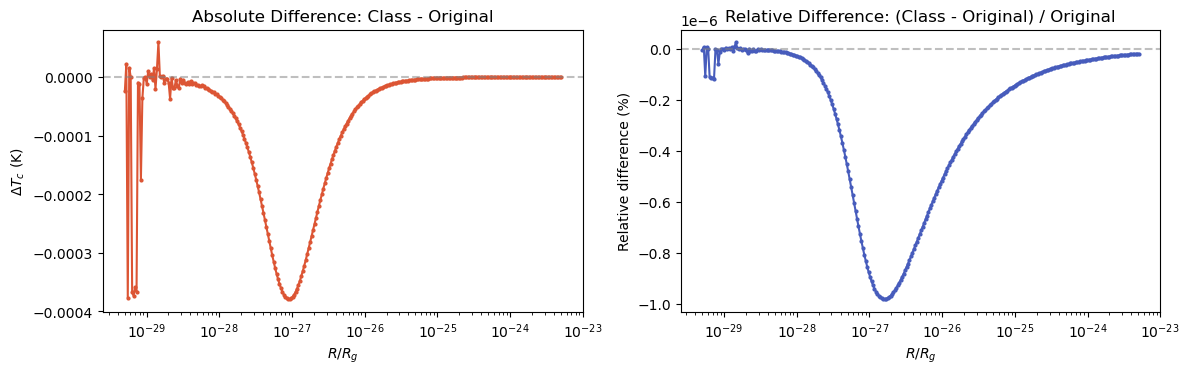

In [79]:
# Plot Tc difference between AGNDisk class and original notebook implementation
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Get common length (in case they have different number of points)
n = min(len(disk_test.model), len(df))
r_rg = disk_test.model["R/Rg"].values[:n]
tc_class = disk_test.model["Tc"].values[:n]
tc_orig = df["Tc"].values[:n]

# Absolute difference
diff_abs = tc_class - tc_orig
axs[0].plot(r_rg, diff_abs, 'o-', markersize=2, color=palette[8])
axs[0].axhline(y=0, color='grey', linestyle='--', alpha=0.5)
axs[0].set_xscale("log")
axs[0].set_xlabel(r"$R/R_g$")
axs[0].set_ylabel(r"$\Delta T_c$ (K)")
axs[0].set_title("Absolute Difference: Class - Original")

# Relative difference (percent)
diff_rel = 100 * (tc_class - tc_orig) / tc_orig
axs[1].plot(r_rg, diff_rel, 'o-', markersize=2, color=palette[2])
axs[1].axhline(y=0, color='grey', linestyle='--', alpha=0.5)
axs[1].set_xscale("log")
axs[1].set_xlabel(r"$R/R_g$")
axs[1].set_ylabel(r"Relative difference (%)")
axs[1].set_title("Relative Difference: (Class - Original) / Original")

plt.tight_layout()

print(f"Max absolute difference: {np.max(np.abs(diff_abs)):.6e} K")
print(f"Max relative difference: {np.max(np.abs(diff_rel)):.6e} %")